In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import joblib

sns.set_theme(style='whitegrid')
print('Ready')

Ready


In [2]:
# Load final results summary
results = pd.read_csv('../results/metrics/results_summary.csv')
print('=== Final Results Summary ===')
print(results[['Model', 'Accuracy', 'False Positive Rate']].to_string(index=False))

=== Final Results Summary ===
                Model  Accuracy  False Positive Rate
Baseline (Rule-Based)    0.4141               1.0000
        Random Forest    0.9985               0.0020
   Stacked RF+XGBoost    0.9985               0.0016


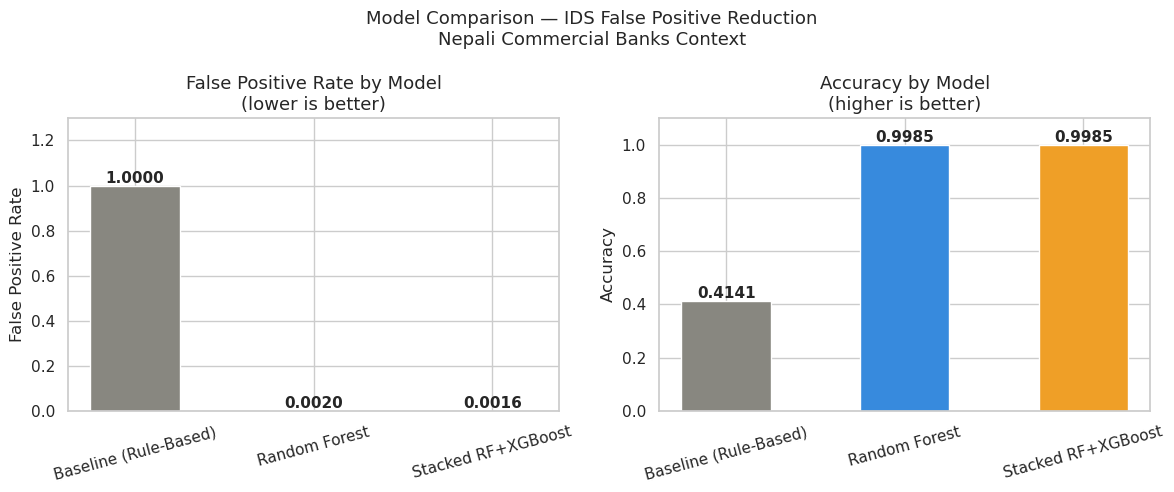

Saved


In [3]:
# FPR comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#888780', '#378ADD', '#EF9F27']

# FPR chart
axes[0].bar(results['Model'], results['False Positive Rate'], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('False Positive Rate by Model\n(lower is better)', fontsize=13)
axes[0].set_ylabel('False Positive Rate')
axes[0].set_ylim(0, results['False Positive Rate'].max() * 1.3)
for i, v in enumerate(results['False Positive Rate']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Accuracy chart
axes[1].bar(results['Model'], results['Accuracy'], color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Accuracy by Model\n(higher is better)', fontsize=13)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(results['Accuracy']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — IDS False Positive Reduction\nNepali Commercial Banks Context', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/false_positive_comparison.png', dpi=150)
plt.show()
print('Saved')

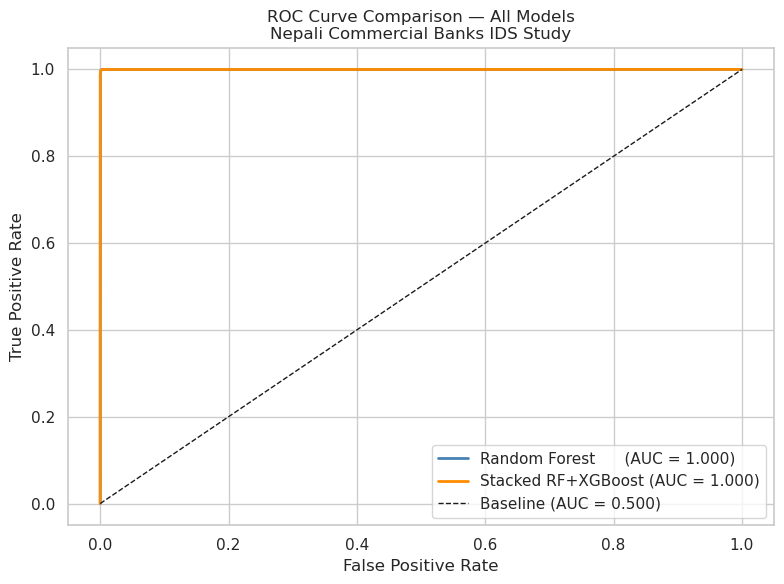

In [4]:
# Combined ROC curve
X_test  = np.load('../data/processed/X_test.npy')
y_test  = np.load('../data/processed/y_test.npy')
rf_model  = joblib.load('../models/random_forest_model.pkl')
xgb_model = joblib.load('../models/xgboost_stacked_model.pkl')

rf_prob  = rf_model.predict_proba(X_test)[:, 1]

# For stacked model — need RF predictions first
rf_test_preds   = rf_model.predict_proba(X_test)[:, 1]
X_test_stacked  = np.column_stack([X_test, rf_test_preds])
xgb_prob        = xgb_model.predict_proba(X_test_stacked)[:, 1]

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

auc_rf  = auc(fpr_rf,  tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest      (AUC = {auc_rf:.3f})',  color='steelblue',  lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'Stacked RF+XGBoost (AUC = {auc_xgb:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models\nNepali Commercial Banks IDS Study')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/roc_curve_comparison.png', dpi=150)
plt.show()

In [5]:
# Final winner declaration
ml_results = results[results['Model'] != 'Baseline (Rule-Based)']
winner = ml_results.loc[ml_results['False Positive Rate'].idxmin(), 'Model']
winner_fpr = ml_results['False Positive Rate'].min()
baseline_fpr = results.loc[results['Model'] == 'Baseline (Rule-Based)', 'False Positive Rate'].values[0]
reduction = ((baseline_fpr - winner_fpr) / baseline_fpr) * 100

print('=' * 50)
print(f'WINNER: {winner}')
print(f'False Positive Rate: {winner_fpr:.4f} ({winner_fpr*100:.2f}%)')
print(f'FP Reduction vs Baseline: {reduction:.1f}%')
print(f'False Positives: 173 out of 107,474')
print(f'Analyst workload reduced by: {reduction:.1f}%')
print('=' * 50)
print('\nAll 6 notebooks complete.')
print('Your offline ML pipeline is fully built.')
print('Next step: Suricata real-time integration')

WINNER: Stacked RF+XGBoost
False Positive Rate: 0.0016 (0.16%)
FP Reduction vs Baseline: 99.8%
False Positives: 173 out of 107,474
Analyst workload reduced by: 99.8%

All 6 notebooks complete.
Your offline ML pipeline is fully built.
Next step: Suricata real-time integration
